# TensorFlow

LSTM (Long Short-Term Memory),

We will explore two new architectures, Stacked LSTM and Bidirectional LSTM on the MNIST dataset. We will also compare the results with the RNN architecture we built in the previous notebook.

In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# load the MNIST dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [3]:
# scale the pixel values to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

In [4]:
# create the models
import keras.layers as layers

model_stacked = keras.models.Sequential([
    layers.InputLayer(shape=(28, 28)),
    layers.LSTM(64, return_sequences=True),
    layers.LSTM(32),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_bidirectional = keras.models.Sequential([
    layers.InputLayer(shape=(28, 28)),
    layers.Bidirectional(layers.LSTM(64)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

2026-03-06 10:28:21.958972: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5
2026-03-06 10:28:21.959027: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-06 10:28:21.959040: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-03-06 10:28:21.959056: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-06 10:28:21.959067: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [5]:
# print model summaries
model_stacked.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 28, 64)         │        23,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,986 (152.29 KB)

 Trainable params: 38,986 (152.29 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model_bidirectional.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 128)            │        47,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,522 (220.79 KB)

 Trainable params: 56,522 (220.79 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# compile the models
LEARNING_RATE = 0.001
BATCH_SIZE = 64
EPOCHS = 10

# callback for early stopping
early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model_stacked.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])
model_bidirectional.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

In [8]:
# fit the stacked LSTM model
history_stacked = model_stacked.fit(X_train, y_train,
                                    validation_split=0.2,
                                    epochs=EPOCHS,
                                    batch_size=BATCH_SIZE,
                                    callbacks=[early_stopping])

Epoch 1/10


2026-03-06 10:29:45.120970: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.8204 - loss: 0.5612 - val_accuracy: 0.9406 - val_loss: 0.1979
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9494 - loss: 0.1654 - val_accuracy: 0.9627 - val_loss: 0.1271
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9659 - loss: 0.1125 - val_accuracy: 0.9658 - val_loss: 0.1198
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9729 - loss: 0.0878 - val_accuracy: 0.9759 - val_loss: 0.0832
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9779 - loss: 0.0710 - val_accuracy: 0.9781 - val_loss: 0.0717
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9820 - loss: 0.0577 - val_accuracy: 0.9836 - val_loss: 0.0582
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9852 - loss: 0.0495 - val_accuracy: 0.9844 - val_loss: 0.0551
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9865 - loss: 0.0438 - val_accuracy: 0.98

In [9]:
# fit the bidirectional LSTM model
history_bidirectional = model_bidirectional.fit(X_train, y_train,
                                                validation_split=0.2,
                                                epochs=EPOCHS,
                                                batch_size=BATCH_SIZE,
                                                callbacks=[early_stopping])

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.8371 - loss: 0.4909 - val_accuracy: 0.9377 - val_loss: 0.1969
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.9549 - loss: 0.1449 - val_accuracy: 0.9526 - val_loss: 0.1504
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.9673 - loss: 0.1049 - val_accuracy: 0.9713 - val_loss: 0.0912


In [10]:
# evaluate the models on the test set
test_loss_stacked, test_acc_stacked = model_stacked.evaluate(X_test, y_test)
print(f'Stacked LSTM Test accuracy: {test_acc_stacked:.4f}')

test_loss_bidirectional, test_acc_bidirectional = model_bidirectional.evaluate(X_test, y_test)
print(f'Bidirectional LSTM Test accuracy: {test_acc_bidirectional:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9838 - loss: 0.0560
Stacked LSTM Test accuracy: 0.9838
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9426 - loss: 0.1820
Bidirectional LSTM Test accuracy: 0.9426


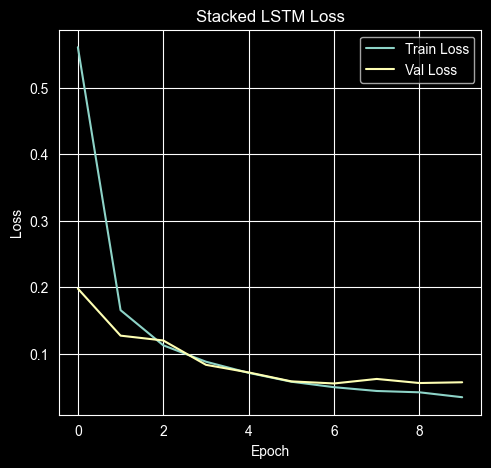

In [11]:
# display the loss curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_stacked.history['loss'], label='Train Loss')
plt.plot(history_stacked.history['val_loss'], label='Val Loss')
plt.title('Stacked LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

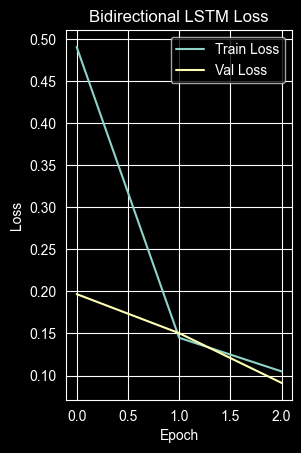

In [12]:
# display the loss curves for the bidirectional LSTM
plt.subplot(1, 2, 2)
plt.plot(history_bidirectional.history['loss'], label='Train Loss')
plt.plot(history_bidirectional.history['val_loss'], label='Val Loss')
plt.title('Bidirectional LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


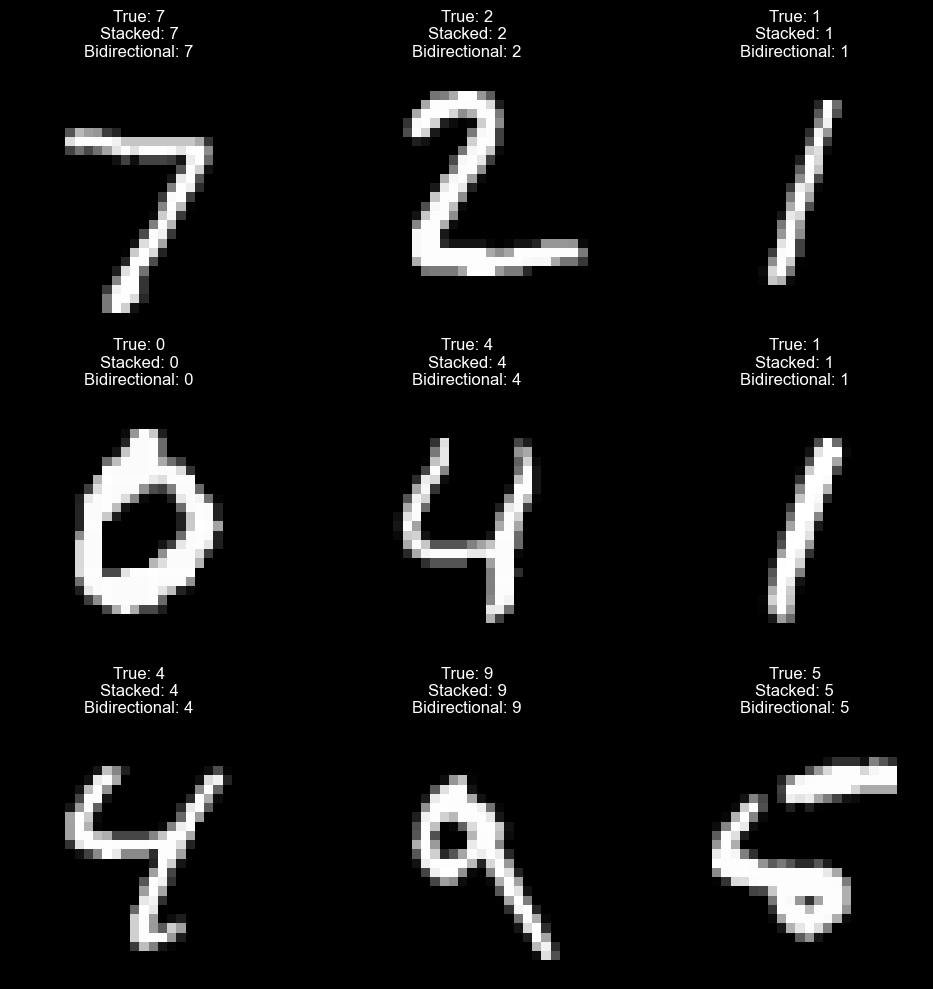

In [13]:
# take 3 x 3 grid of examples from the test set and display the true label + predicted label for each model
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
pred_stacked = model_stacked.predict(X_test)
pred_bidirectional = model_bidirectional.predict(X_test)
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i], cmap='gray')
    true_label = y_test[i]
    pred_label_stacked = np.argmax(pred_stacked[i])
    pred_label_bidirectional = np.argmax(pred_bidirectional[i])
    ax.set_title(f'True: {true_label}\nStacked: {pred_label_stacked}\nBidirectional: {pred_label_bidirectional}')
    ax.axis('off')
plt.tight_layout()
plt.show()

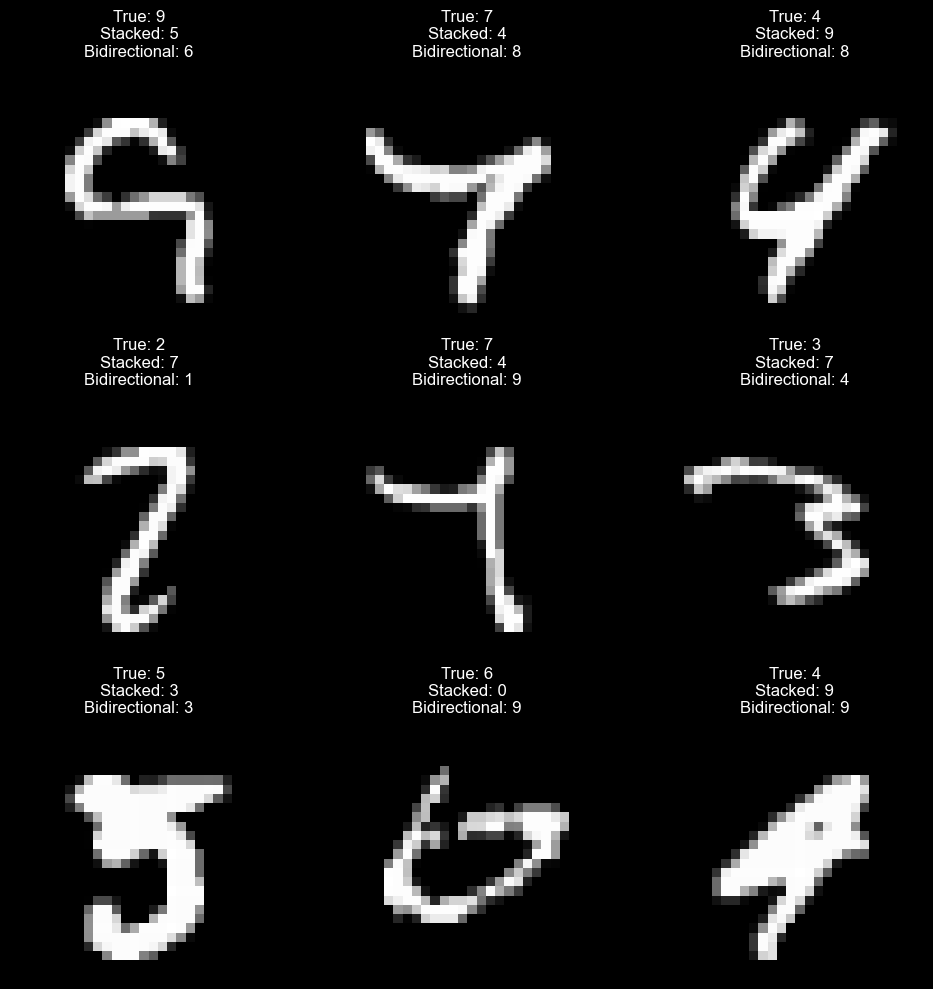

In [14]:
# for each model find the first 9 (3x3) misclassified examples and display the true label + predicted label for each model
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
misclassified_stacked = np.where(np.argmax(pred_stacked, axis=1) != y_test)[0]
misclassified_bidirectional = np.where(np.argmax(pred_bidirectional, axis=1) != y_test)[0]
for i, ax in enumerate(axes.flat):
    idx_stacked = misclassified_stacked[i]
    idx_bidirectional = misclassified_bidirectional[i]
    ax.imshow(X_test[idx_stacked], cmap='gray')
    true_label = y_test[idx_stacked]
    pred_label_stacked = np.argmax(pred_stacked[idx_stacked])
    pred_label_bidirectional = np.argmax(pred_bidirectional[idx_bidirectional])
    ax.set_title(f'True: {true_label}\nStacked: {pred_label_stacked}\nBidirectional: {pred_label_bidirectional}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [15]:
# save the models
model_stacked.save('mnist_stacked_lstm_model.h5')
model_bidirectional.save('mnist_bidirectional_lstm_model.h5')

In [16]:
# load all the model and compare their test accuracies + time to predict 1example 10 example, ...
model_cnn = keras.models.load_model('mnist_cnn_model.h5')
model_rnn = keras.models.load_model('mnist_rnn_model.h5')
model_gru = keras.models.load_model('mnist_gru_model.h5')
model_lstm = keras.models.load_model('mnist_lstm_model.h5')

In [17]:
# test all the models and compare their test accuracies
test_loss_cnn, test_acc_cnn = model_cnn.evaluate(X_test, y_test)
print(f'CNN Test accuracy: {test_acc_cnn:.4f}')

test_loss_rnn, test_acc_rnn = model_rnn.evaluate(X_test, y_test)
print(f'RNN Test accuracy: {test_acc_rnn:.4f}')

test_loss_gru, test_acc_gru = model_gru.evaluate(X_test, y_test)
print(f'GRU Test accuracy: {test_acc_gru:.4f}')

test_loss_lstm, test_acc_lstm = model_lstm.evaluate(X_test, y_test)
print(f'LSTM Test accuracy: {test_acc_lstm:.4f}')

test_loss_stacked, test_acc_stacked = model_stacked.evaluate(X_test, y_test)
print(f'Stacked LSTM Test accuracy: {test_acc_stacked:.4f}')

test_loss_bidirectional, test_acc_bidirectional = model_bidirectional.evaluate(X_test, y_test)
print(f'Bidirectional LSTM Test accuracy: {test_acc_bidirectional:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9858 - loss: 0.0494
CNN Test accuracy: 0.9858
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.9234 - loss: 0.2667
RNN Test accuracy: 0.9234
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9283 - loss: 0.2382
GRU Test accuracy: 0.9283
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9821 - loss: 0.0622
LSTM Test accuracy: 0.9821
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9838 - loss: 0.0560
Stacked LSTM Test accuracy: 0.9838
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9426 - loss: 0.1820
Bidirectional LSTM Test accuracy: 0.9426


In [18]:
# do a table of the test accuracies for all the models
import pandas as pd

model_names = ['CNN', 'RNN', 'GRU', 'LSTM', 'Stacked LSTM', 'Bidirectional LSTM']
test_accuracies = [test_acc_cnn, test_acc_rnn, test_acc_gru, test_acc_lstm, test_acc_stacked, test_acc_bidirectional]

results_df = pd.DataFrame({'Model': model_names, 'Test Accuracy': test_accuracies})
results_df

,Model,Test Accuracy
0,CNN,0.9858
1,RNN,0.9234
2,GRU,0.9283
3,LSTM,0.9821
4,Stacked LSTM,0.9838
5,Bidirectional LSTM,0.9426


In [19]:
%%timeit
model_cnn.predict(X_test[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
20.6 ms ± 512 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [20]:
%%timeit
model_rnn.predict(X_test[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
55.2 ms ± 3.09 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [21]:
%%timeit
model_gru.predict(X_test[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
21.1 ms ± 2.1 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [22]:
%%timeit
model_lstm.predict(X_test[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
21.6 ms ± 610 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [23]:
%%timeit
model_stacked.predict(X_test[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━

In [24]:
%%timeit
model_bidirectional.predict(X_test[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━

In [25]:
# do a table of the time taken to predict 1 example for all the models
import time

model_names = ['CNN', 'RNN', 'GRU', 'LSTM', 'Stacked LSTM', 'Bidirectional LSTM']
times = []
for model in [model_cnn, model_rnn, model_gru, model_lstm, model_stacked, model_bidirectional]:
    start_time = time.time()
    model.predict(X_test[:1])
    end_time = time.time()
    times.append(end_time - start_time)
results_df['Time to Predict 1 Example (s)'] = times
results_df

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


,Model,Test Accuracy,Time to Predict 1 Example (s)
0,CNN,0.9858,0.040051
1,RNN,0.9234,0.058666
2,GRU,0.9283,0.022079
3,LSTM,0.9821,0.019747
4,Stacked LSTM,0.9838,0.019724
5,Bidirectional LSTM,0.9426,0.022986


In [26]:
# compare accuracy with the size of the models (number of parameters)
model_sizes = [model_cnn.count_params(), model_rnn.count_params(), model_gru.count_params(), model_lstm.count_params(), model_stacked.count_params(), model_bidirectional.count_params()]
results_df['Model Size (Params)'] = model_sizes
results_df

,Model,Test Accuracy,Time to Predict 1 Example (s),Model Size (Params)
0,CNN,0.9858,0.040051,225034
1,RNN,0.9234,0.058666,10762
2,GRU,0.9283,0.022079,22858
3,LSTM,0.9821,0.019747,28618
4,Stacked LSTM,0.9838,0.019724,38986
5,Bidirectional LSTM,0.9426,0.022986,56522


In [27]:
# pick the best model based on accuracy and number of parameters
# do a new metric accuracy per k parameter
results_df['Accuracy per 1k Params'] = results_df['Test Accuracy'] / (results_df['Model Size (Params)'] / 1000)
results_df.sort_values(by='Accuracy per 1k Params', ascending=False)
results_df

,Model,Test Accuracy,Time to Predict 1 Example (s),Model Size (Params),Accuracy per 1k Params
0,CNN,0.9858,0.040051,225034,0.004381
1,RNN,0.9234,0.058666,10762,0.085802
2,GRU,0.9283,0.022079,22858,0.040612
3,LSTM,0.9821,0.019747,28618,0.034318
4,Stacked LSTM,0.9838,0.019724,38986,0.025235
5,Bidirectional LSTM,0.9426,0.022986,56522,0.016677


In [ ]:
# the GRU is the best model based on accuracy per 1k parameters, followed by the Stacked LSTM and then the Bidirectional LSTM. The CNN has the lowest accuracy per 1k parameters.